## 1. Load Dataset

In [1]:
# 1. Import Libraries

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

from imblearn.over_sampling import SMOTE

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout

pd.set_option("display.max_columns", None)

In [3]:
# Load the dataset

df = pd.read_csv("creditcard.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

PermissionError: [Errno 13] Permission denied: 'creditcard.csv'

## 2. Data Inspection

In [4]:
# Basic information about the dataset

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types and non-null values:")
df.info()

NameError: name 'df' is not defined

In [5]:
# Statistical summary

df.describe()

NameError: name 'df' is not defined

In [6]:
# Target distribution

print("Class distribution:")
print(df["Class"].value_counts())

print("\nClass percentages:")
print(df["Class"].value_counts(normalize=True) * 100)

Class distribution:


NameError: name 'df' is not defined

## 3. Missing Values

In [7]:
# Check missing values

missing_values = df.isnull().sum()

print("Total missing values:", missing_values.sum())

# Show only columns that contain missing values
missing_values[missing_values > 0]

NameError: name 'df' is not defined

## 4. Duplicates

In [8]:
# Check duplicated rows

duplicate_count = df.duplicated().sum()

print("Number of duplicated rows:", duplicate_count)

NameError: name 'df' is not defined

In [9]:
# Remove duplicated rows
# Removed BEFORE the train/test split so that no duplicate pair can end up split across
# the training and testing sets (which would cause data leakage).

print("Before removing duplicates:", df.shape)
print(df["Class"].value_counts())

df = df.drop_duplicates().reset_index(drop=True)

print("\nAfter removing duplicates:", df.shape)
print(df["Class"].value_counts())
print("\nFraud percentage after removing duplicates:", df["Class"].mean() * 100)

NameError: name 'df' is not defined

# PREPROCESSING

This section prepares the cleaned dataset for modeling. The EDA and visualization section follows it so the workflow is easy to present by role.


## 5. Feature Engineering — Time

In [10]:
# Convert Time (seconds since first transaction) into a 24-hour cycle (0-23)
# Note: Time is elapsed time since the first transaction, not a real timestamp.
# Therefore, Hour is an approximate cyclic time feature relative to the dataset start.

df["Hour"] = (df["Time"] // 3600) % 24

print(df[["Time", "Hour"]].head())
print("\nHour value counts:")
print(df["Hour"].value_counts().sort_index())

# Drop the raw Time column now that we have the engineered Hour feature
df = df.drop("Time", axis=1)

print("\nShape after feature engineering:", df.shape)


NameError: name 'df' is not defined

## 6. Outlier Handling — Amount

In [11]:
# Log-transform Amount to reduce the influence of extreme values (no rows are removed)

print("Amount stats before transform:")
print(df["Amount"].describe())

df["Amount"] = np.log1p(df["Amount"])

print("\nAmount stats after log1p transform:")
print(df["Amount"].describe())

Amount stats before transform:


NameError: name 'df' is not defined

## 7. Train / Test Split

In [12]:
# Separate features and target

X = df.drop("Class", axis=1)
y = df["Class"]

print("X shape:", X.shape)
print("y shape:", y.shape)

NameError: name 'df' is not defined

In [12]:
# 9. Train / Validation / Test Split

# First split:
# 80% temporary training
# 20% final test

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# Second split From the 80% training data:
# 80% becomes training
# 20% becomes validation

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=y_train_full
)


print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

print("\ny_train:", y_train.shape)
print("y_val  :", y_val.shape)
print("y_test :", y_test.shape)


print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nValidation class distribution:")
print(y_val.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

X_train: (181584, 30)
X_val  : (45396, 30)
X_test : (56746, 30)

y_train: (181584,)
y_val  : (45396,)
y_test : (56746,)

Training class distribution:
Class
0    181282
1       302
Name: count, dtype: int64

Validation class distribution:
Class
0    45320
1       76
Name: count, dtype: int64

Testing class distribution:
Class
0    56651
1       95
Name: count, dtype: int64


## 8. Scaling

In [13]:
# 10. Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)


print("Scaling completed.")

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_val_scaled shape  :", X_val_scaled.shape)
print("X_test_scaled shape :", X_test_scaled.shape)

Scaling completed.
X_train_scaled shape: (181584, 30)
X_val_scaled shape  : (45396, 30)
X_test_scaled shape : (56746, 30)


## 9. Handle Class Imbalance — SMOTE

In [14]:
# Check the imbalance before SMOTE

print("Before SMOTE:")

print(pd.Series(y_train).value_counts())

print(
    "\nFraud percentage in training data:",
    y_train.mean() * 100
)

Before SMOTE:
Class
0    181282
1       302
Name: count, dtype: int64

Fraud percentage in training data: 0.16631421270596528


In [15]:
# Apply SMOTE ONLY to training data

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled,
    y_train)

print("After SMOTE:")

print(
    pd.Series(y_train_resampled).value_counts())

print(
    "\nX_train_resampled shape:",
    X_train_resampled.shape)

print(
    "y_train_resampled shape:",
    y_train_resampled.shape)

After SMOTE:
Class
0    181282
1    181282
Name: count, dtype: int64

X_train_resampled shape: (362564, 30)
y_train_resampled shape: (362564,)


## 10. Final Data Ready for Modeling

In [16]:
# Convert scaled/resampled arrays back to DataFrames for easier inspection

X_train_resampled = pd.DataFrame(
    X_train_resampled,
    columns=X_train.columns)

X_val_scaled = pd.DataFrame(
    X_val_scaled,
    columns=X_val.columns)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns)


print(
    "Final training features:",
    X_train_resampled.shape)

print(
    "Final validation features:",
    X_val_scaled.shape)

print(
    "Final testing features:",
    X_test_scaled.shape)


print("\nFinal training target distribution:")
print(pd.Series(y_train_resampled).value_counts())

print("\nFinal validation target distribution:")
print(y_val.value_counts())

print("\nFinal testing target distribution:")
print(y_test.value_counts())

Final training features: (362564, 30)
Final validation features: (45396, 30)
Final testing features: (56746, 30)

Final training target distribution:
Class
0    181282
1    181282
Name: count, dtype: int64

Final validation target distribution:
Class
0    45320
1       76
Name: count, dtype: int64

Final testing target distribution:
Class
0    56651
1       95
Name: count, dtype: int64


In [17]:
# Save scaler

joblib.dump(scaler,"scaler.pkl")
print("Scaler saved to scaler.pkl")

# Save processed datasets

X_train_resampled.to_csv("X_train_resampled.csv",index=False)

pd.Series(y_train_resampled,name="Class").to_csv("y_train_resampled.csv",index=False)

X_val_scaled.to_csv("X_val_scaled.csv",index=False)

y_val.to_csv("y_val.csv",index=False)

X_test_scaled.to_csv("X_test_scaled.csv",index=False)

y_test.to_csv("y_test.csv",index=False)

print(
    "Processed train/validation/test files saved successfully."
)

Scaler saved to scaler.pkl
Processed train/validation/test files saved successfully.


# EXPLORATORY DATA ANALYSIS (EDA) & VISUALIZATION

This section contains the EDA and all visualizations together, after preprocessing, for easier presentation and discussion.


## 1. Fraud vs Normal Distribution

`Class = 0` represents a normal transaction and `Class = 1` represents fraud.

Because fraud is rare, the percentage is more informative than only looking at the raw counts.


In [18]:
class_counts = df["Class"].value_counts().sort_index()
class_percent = df["Class"].value_counts(normalize=True).sort_index() * 100

distribution = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percent
})

distribution.index = ["Normal (0)", "Fraud (1)"]

distribution

,Count,Percentage
Normal (0),283253,99.83329
Fraud (1),473,0.16671


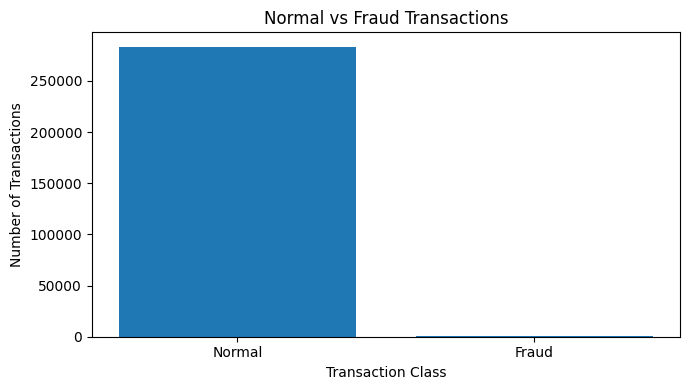

In [19]:
plt.figure(figsize=(7, 4))
plt.bar(["Normal", "Fraud"], class_counts.values)
plt.title("Normal vs Fraud Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

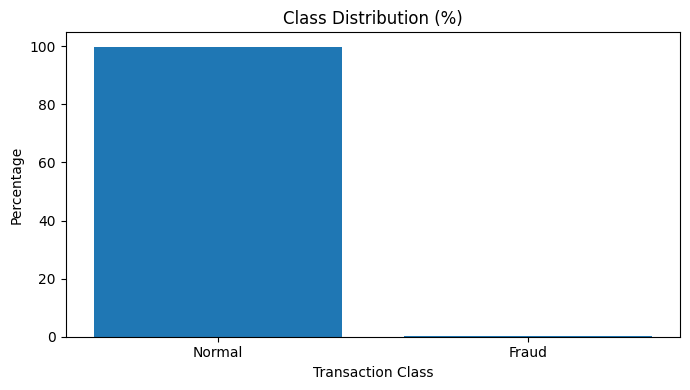

In [20]:
plt.figure(figsize=(7, 4))
plt.bar(["Normal", "Fraud"], class_percent.values)
plt.title("Class Distribution (%)")
plt.xlabel("Transaction Class")
plt.ylabel("Percentage")
plt.tight_layout()
plt.show()

## 2. Transaction Amount Analysis

The `Amount` feature is highly skewed.


In [21]:
print("Overall Amount statistics:")
print(df["Amount"].describe())

print("\nAverage amount by class:")
print(df.groupby("Class")["Amount"].agg(["count", "mean", "median", "min", "max"]))

Overall Amount statistics:
count    283726.000000
mean          3.153760
std           1.657080
min           0.000000
25%           1.887070
50%           3.135494
75%           4.363226
max          10.153941
Name: Amount, dtype: float64

Average amount by class:
        count      mean    median  min        max
Class                                            
0      283253  3.154289  3.135494  0.0  10.153941
1         473  2.837549  2.381396  0.0   7.662407


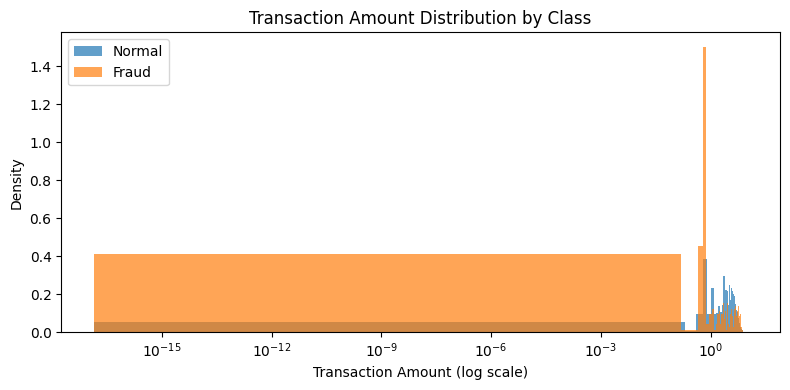

In [22]:
plt.figure(figsize=(8, 4))
plt.hist(df.loc[df["Class"] == 0, "Amount"], bins=50, alpha=0.7, label="Normal", density=True)
plt.hist(df.loc[df["Class"] == 1, "Amount"], bins=50, alpha=0.7, label="Fraud", density=True)
plt.xscale("log")
plt.title("Transaction Amount Distribution by Class")
plt.xlabel("Transaction Amount (log scale)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 800x400 with 0 Axes>

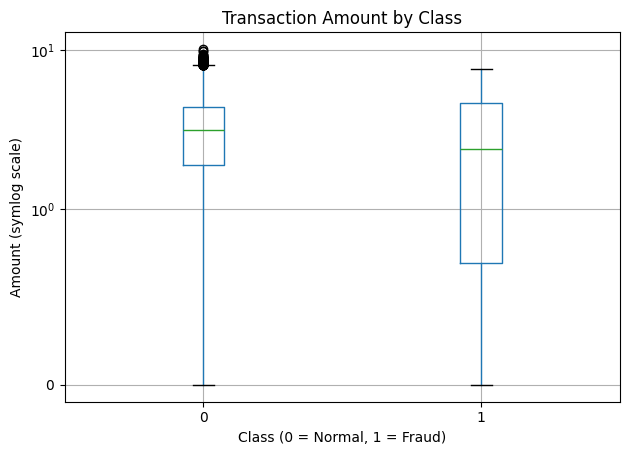

In [23]:
plt.figure(figsize=(8, 4))
df.boxplot(column="Amount", by="Class")
plt.yscale("symlog", linthresh=1)
plt.title("Transaction Amount by Class")
plt.suptitle("")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Amount (symlog scale)")
plt.tight_layout()
plt.show()

### Insight

Transaction amount alone does not clearly separate fraud from normal transactions. Fraud can occur at relatively small amounts as well as larger amounts, so the model should use the other transaction features rather than relying on `Amount` alone.

## 3. Time Analysis

`Time` is measured in seconds from the first transaction in the dataset, so it is an elapsed-time variable rather than a real-world timestamp.
For easier interpretation, we convert it into an approximate **24-hour cycle** using `(Time // 3600) % 24`.

This feature should therefore be interpreted as a relative/cyclic hour index within the dataset, **not as a verified clock hour of the day**.
The same engineered `Hour` feature is used by the modeling pipeline.


In [24]:
eda_df = df.copy()

# `Hour` was created during preprocessing, so no raw Time column is required here.
if "Hour" not in eda_df.columns:
    raise ValueError("Hour column is missing. Run the preprocessing section first.")

hour_summary = eda_df.groupby(["Hour", "Class"]).size().unstack(fill_value=0)
hour_summary = hour_summary.reindex(columns=[0, 1], fill_value=0)
hour_summary.columns = ["Normal", "Fraud"]

hour_summary


,Normal,Fraud
Hour,,
0.0,7641,6
1.0,4198,10
2.0,3260,48
3.0,3470,17
4.0,2181,23
5.0,2977,11
6.0,4073,9
7.0,7210,23
8.0,10223,9


In [25]:
fraud_by_hour = eda_df.groupby("Hour")["Class"].agg(["count", "sum"])
fraud_by_hour["fraud_rate_%"] = fraud_by_hour["sum"] / fraud_by_hour["count"] * 100

print("Hours with the highest observed fraud rate:")
fraud_by_hour.sort_values("fraud_rate_%", ascending=False).head(5)


Hours with the highest observed fraud rate:


,count,sum,fraud_rate_%
Hour,,,
2.0,3308,48,1.451028
4.0,2204,23,1.043557
3.0,3487,17,0.487525
5.0,2988,11,0.368139
7.0,7233,23,0.317987


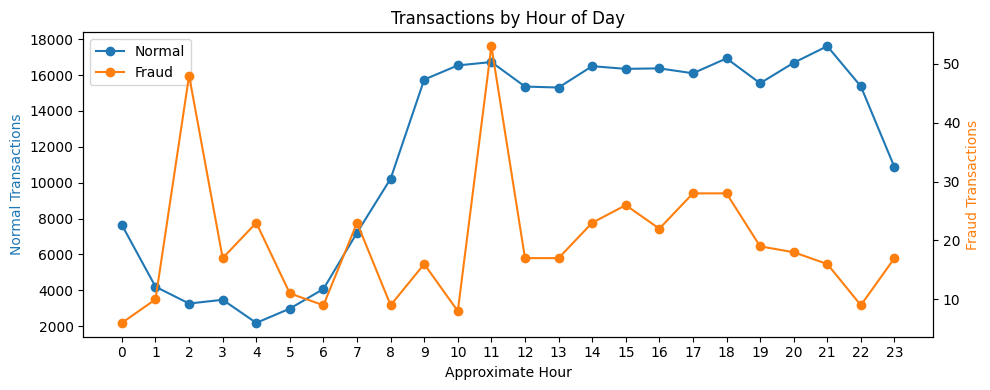

In [26]:
fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()

ax1.plot(hour_summary.index, hour_summary["Normal"], marker="o", color="tab:blue", label="Normal")
ax2.plot(hour_summary.index, hour_summary["Fraud"], marker="o", color="tab:orange", label="Fraud")

ax1.set_xlabel("Approximate Hour")
ax1.set_ylabel("Normal Transactions", color="tab:blue")
ax2.set_ylabel("Fraud Transactions", color="tab:orange")
ax1.set_xticks(range(24))
plt.title("Transactions by Hour of Day")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

### Insight

Transaction activity changes over time, and the fraud rate is not necessarily identical across all hours. However, because some hours contain many fewer transactions than others, the fraud-rate results should be interpreted together with the transaction count rather than treated as a standalone rule.

## 4. Correlation Analysis

The dataset contains anonymized PCA features (`V1`–`V28`) plus `Time`, `Amount`, and `Class`.

A correlation matrix helps identify which features have stronger linear relationships with the target. Correlation does **not** prove causation and may miss nonlinear relationships.

In [27]:
corr = df.corr(numeric_only=True)

class_corr = corr["Class"].drop("Class").sort_values()

print("Features most negatively correlated with Class:")
print(class_corr.head(5))

print("\nFeatures most positively correlated with Class:")
print(class_corr.tail(5))


Features most negatively correlated with Class:
V17   -0.313498
V14   -0.293375
V12   -0.250711
V10   -0.206971
V16   -0.187186
Name: Class, dtype: float64

Features most positively correlated with Class:
V8     0.033068
V19    0.033631
V2     0.084624
V4     0.129326
V11    0.149067
Name: Class, dtype: float64


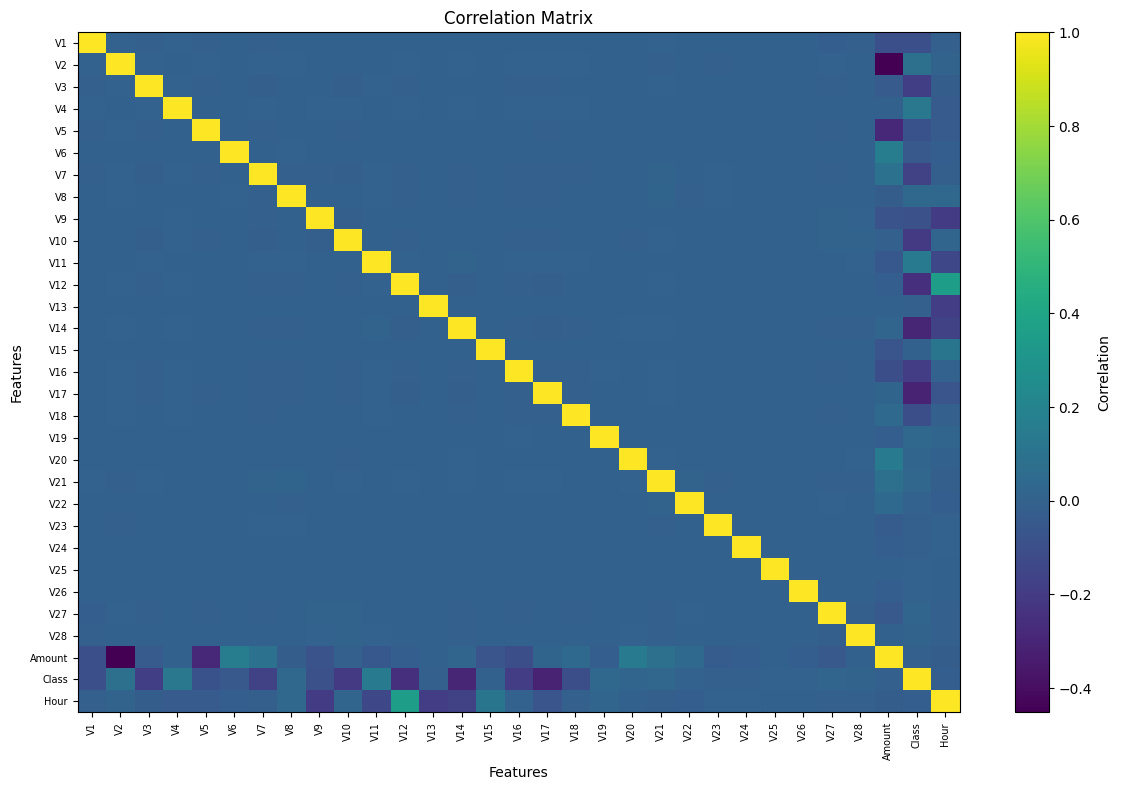

In [28]:
plt.figure(figsize=(12, 8))
plt.imshow(corr, aspect="auto", interpolation="nearest")
plt.colorbar(label="Correlation")
plt.title("Correlation Matrix")
plt.xlabel("Features")
plt.ylabel("Features")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=7)
plt.yticks(range(len(corr.columns)), corr.columns, fontsize=7)
plt.tight_layout()
plt.show()

## 5. Most Relevant Features for Fraud

Instead of showing many repetitive plots, we focus on the features with the strongest absolute linear correlation with `Class`.

These are useful for understanding the dataset, but they are **not automatically the final features** for the neural networks.


In [29]:
top_corr = class_corr.abs().sort_values(ascending=False).head(10)
top_features = top_corr.index

print("Top 10 features by absolute correlation with Class:")
print(pd.DataFrame({
    "Feature": top_features,
    "Correlation_with_Class": corr.loc[top_features, "Class"].values,
    "Absolute_Correlation": top_corr.values
}))


Top 10 features by absolute correlation with Class:
  Feature  Correlation_with_Class  Absolute_Correlation
0     V17               -0.313498              0.313498
1     V14               -0.293375              0.293375
2     V12               -0.250711              0.250711
3     V10               -0.206971              0.206971
4     V16               -0.187186              0.187186
5      V3               -0.182322              0.182322
6      V7               -0.172347              0.172347
7     V11                0.149067              0.149067
8      V4                0.129326              0.129326
9     V18               -0.105340              0.105340


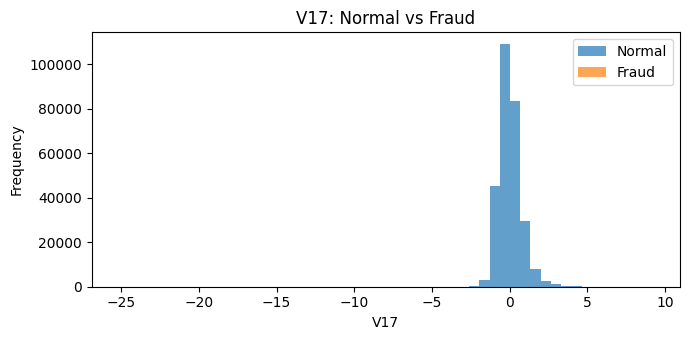

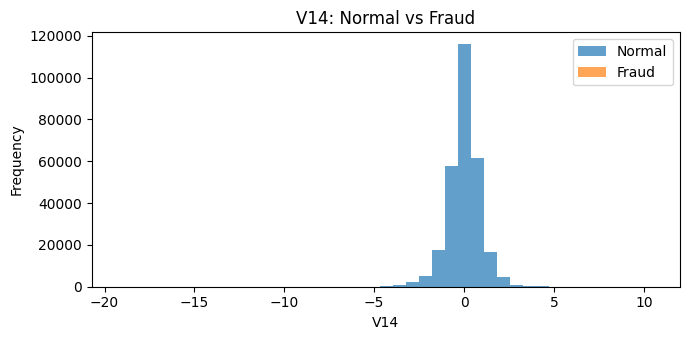

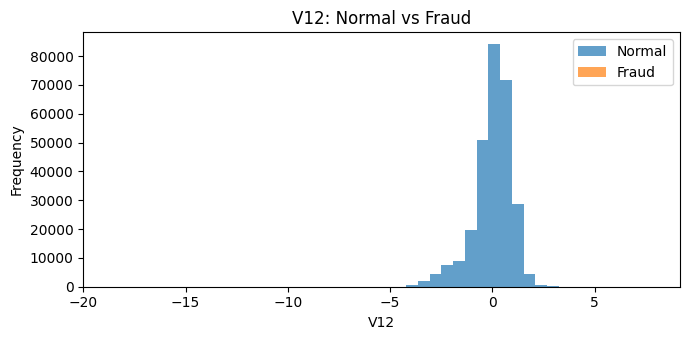

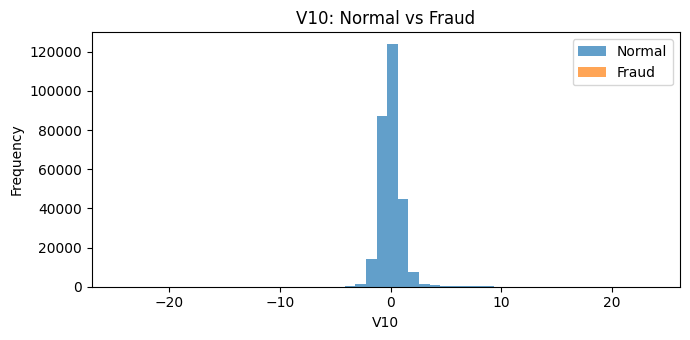

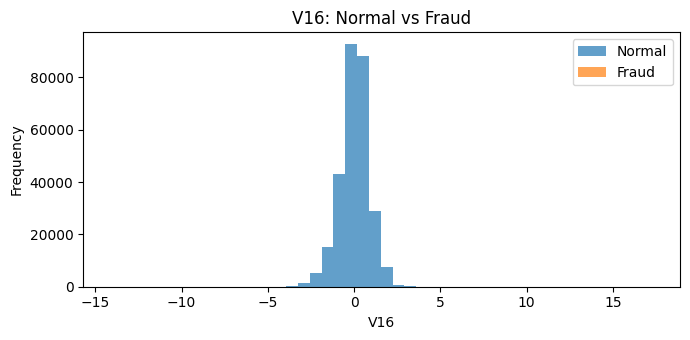

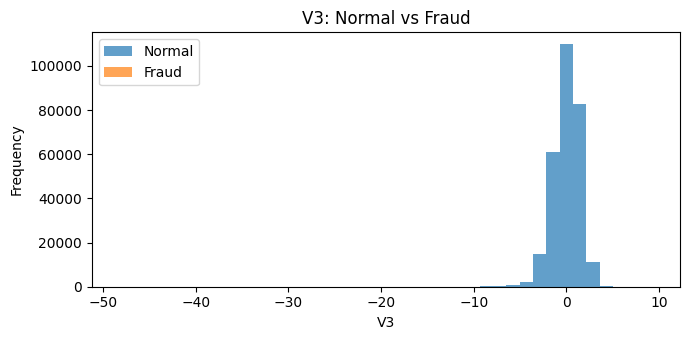

In [30]:
for feature in top_features[:6]:
    plt.figure(figsize=(7, 3.5))
    plt.hist(df.loc[df["Class"] == 0, feature], bins=40, alpha=0.7, label="Normal")
    plt.hist(df.loc[df["Class"] == 1, feature], bins=40, alpha=0.7, label="Fraud")
    plt.title(f"{feature}: Normal vs Fraud")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Main EDA Findings

1. **The dataset is highly imbalanced:** fraud transactions are much less common than normal transactions.
2. **Amount is strongly skewed:** the log transformation reduces the influence of extreme values.
3. **Amount alone is not enough:** fraudulent transactions are not restricted to one specific amount range.
4. **Time patterns vary:** transaction activity and observed fraud rate change across approximate hours of the day.
5. **Several anonymized PCA features show stronger correlation with fraud:** these features are useful candidates for model learning.
6. **EDA supports the modeling strategy:** fraud-sensitive metrics such as recall, F1-score, ROC-AUC and PR-AUC are important.


# **MLP MODEL**

In [31]:
#BUILD MLP MODEL

mlp = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.40),

    Dense(64, activation='relu'),
    Dropout(0.30),

    Dense(32, activation='relu'),
    Dropout(0.20),

    Dense(16, activation='relu'),

    Dense(1, activation='sigmoid')
])

mlp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,849 (58.00 KB)

 Trainable params: 14,849 (58.00 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# COMPILE MLP MODEL

mlp.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='roc_auc'),
        tf.keras.metrics.AUC(name='pr_auc', curve='PR')
    ]
)


In [33]:
# TRAIN MLP MODEL WITH EARLY STOPPING + LEARNING-RATE SCHEDULING

early_stop_mlp = tf.keras.callbacks.EarlyStopping(
    monitor='val_pr_auc',
    mode='max',
    patience=7,
    min_delta=0.0005,
    restore_best_weights=True
)

reduce_lr_mlp = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_pr_auc',
    mode='max',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history = mlp.fit(
    X_train_resampled,
    y_train_resampled,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=256,
    shuffle=True,
    callbacks=[early_stop_mlp, reduce_lr_mlp],
    verbose=1
)

print(f'Best epoch: {np.argmax(history.history["val_pr_auc"]) + 1}')
print(f'Best validation PR-AUC: {max(history.history["val_pr_auc"]):.4f}')


Epoch 1/50
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.9766 - loss: 0.0627 - pr_auc: 0.9972 - roc_auc: 0.9975 - val_accuracy: 0.9973 - val_loss: 0.0126 - val_pr_auc: 0.7310 - val_roc_auc: 0.9401 - learning_rate: 0.0010
Epoch 2/50
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9978 - loss: 0.0103 - pr_auc: 0.9993 - roc_auc: 0.9996 - val_accuracy: 0.9988 - val_loss: 0.0098 - val_pr_auc: 0.7739 - val_roc_auc: 0.9404 - learning_rate: 0.0010
Epoch 3/50
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9987 - loss: 0.0063 - pr_auc: 0.9994 - roc_auc: 0.9997 - val_accuracy: 0.9990 - val_loss: 0.0103 - val_pr_auc: 0.7597 - val_roc_auc: 0.9340 - learning_rate: 0.0010
Epoch 4/50
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9990 - loss: 0.0048 - pr_auc: 0.9995 - roc_auc: 0.9997 - val_accuracy: 0.9992 - val_loss: 0.0102 - val_pr_auc: 0.7980 - val_roc_auc: 0.9340 - learning_rate: 0.0010
Epoch 5/50
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.999

In [ ]:
# SAVE THE TRAINED MLP MODEL

mlp.save("mlp_model.keras")
print("MLP model saved to mlp_model.keras")

# Verify: Load the saved model and check predictions
mlp_loaded = tf.keras.models.load_model("mlp_model.keras")
print("✓ Model loaded successfully from mlp_model.keras")

# Quick sanity check: predictions should match the original model
y_val_prob_verify = mlp_loaded.predict(X_val_scaled, verbose=0).ravel()
y_test_prob_verify = mlp_loaded.predict(X_test_scaled, verbose=0).ravel()

# Verify shapes match
assert y_val_prob_verify.shape == y_val_prob.shape, f"Validation shape mismatch: {y_val_prob_verify.shape} vs {y_val_prob.shape}"
assert y_test_prob_verify.shape == y_test_prob.shape, f"Test shape mismatch: {y_test_prob_verify.shape} vs {y_test_prob.shape}"

# Verify predictions are identical (within floating point precision)
assert np.allclose(y_val_prob_verify, y_val_prob, atol=1e-6), "Validation predictions do not match original model"
assert np.allclose(y_test_prob_verify, y_test_prob, atol=1e-6), "Test predictions do not match original model"

print("✓ Validation predictions shape:", y_val_prob_verify.shape, "- matches original")
print("✓ Test predictions shape:", y_test_prob_verify.shape, "- matches original")
print("✓ All predictions are numerically identical to the original model")
print("\n✅ MLP model successfully saved and verified!")

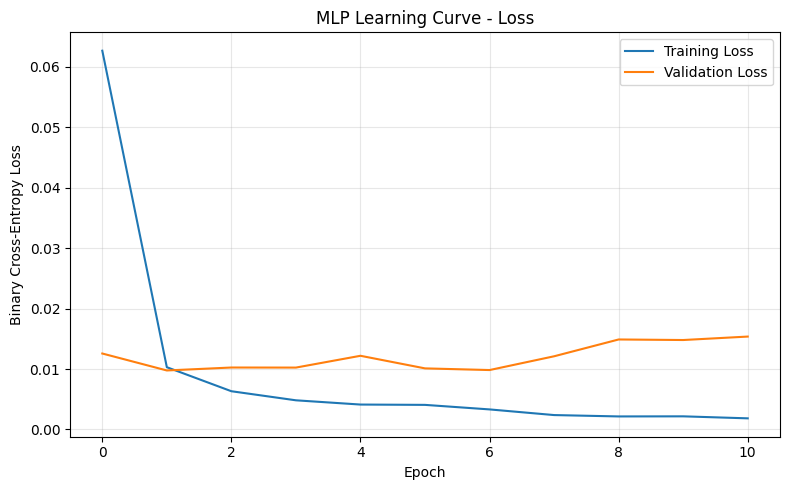

In [34]:
# MLP LEARNING CURVE - LOSS

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.title('MLP Learning Curve - Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


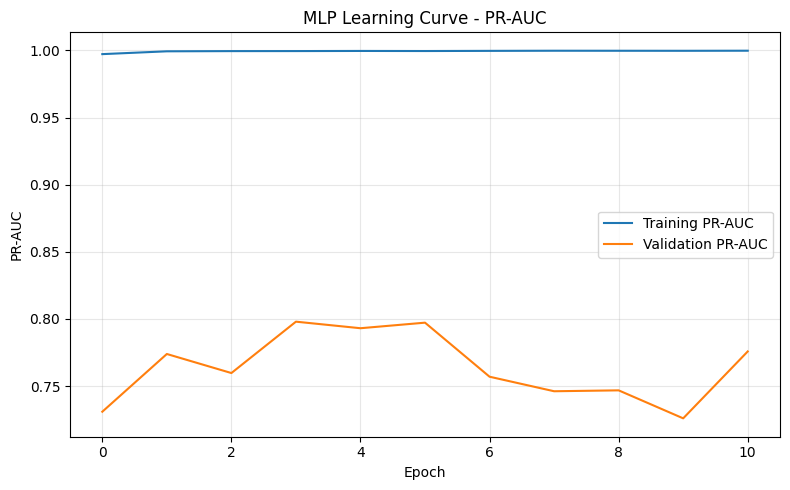

In [35]:
# MLP LEARNING CURVE - PR-AUC

plt.figure(figsize=(8, 5))
plt.plot(history.history['pr_auc'], label='Training PR-AUC')
plt.plot(history.history['val_pr_auc'], label='Validation PR-AUC')
plt.xlabel('Epoch')
plt.ylabel('PR-AUC')
plt.title('MLP Learning Curve - PR-AUC')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


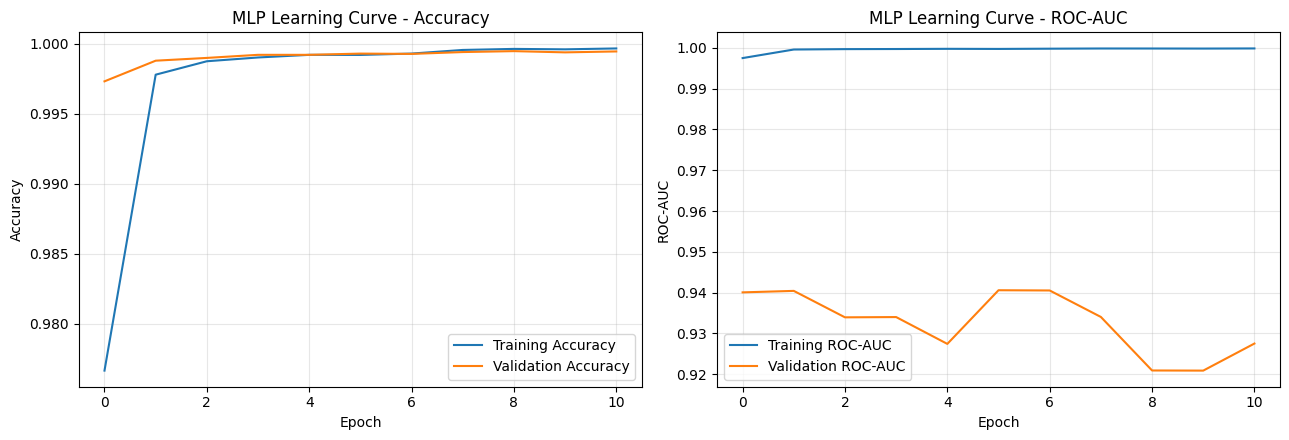

In [36]:
# OPTIONAL TRAINING DIAGNOSTICS - ACCURACY AND ROC-AUC

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('MLP Learning Curve - Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['roc_auc'], label='Training ROC-AUC')
axes[1].plot(history.history['val_roc_auc'], label='Validation ROC-AUC')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('MLP Learning Curve - ROC-AUC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### MLP Training Notes

- **EarlyStopping** monitors validation PR-AUC and restores the best weights, reducing the risk of overfitting.
- **ReduceLROnPlateau** lowers the learning rate when validation PR-AUC stops improving, allowing finer optimization.
- **PR-AUC** is tracked because the fraud class is highly imbalanced; it is more informative than accuracy alone for this problem.
- The validation set is used for training monitoring only. The final test set remains untouched until final evaluation and threshold application.


In [37]:
#VALIDATION PROBABILITIES

y_val_prob = mlp.predict(
X_val_scaled,
verbose=0
).ravel()

### Why optimize the decision threshold?

The default classification threshold of 0.50 is not necessarily appropriate for fraud detection because the dataset is highly imbalanced and missing a fraudulent transaction can be costly.

For the MLP, the threshold is selected using the **validation set only**. We prioritize **Recall** because detecting as many fraudulent transactions as possible is important. The threshold is then kept fixed and applied to the untouched test set, which prevents test-set information from influencing model selection.


In [38]:
# 6. FIND BEST THRESHOLD USING VALIDATION
#
# We search for the threshold that gives
# the highest Recall.

thresholds = np.arange(
    0.01,
    1.00,
    0.01
)

best_threshold = 0.5
best_recall = -1

for threshold in thresholds:

    y_val_pred = (
        y_val_prob >= threshold
    ).astype(int)

    recall = recall_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    if recall > best_recall:

        best_recall = recall
        best_threshold = threshold


print("\n====================================")
print("VALIDATION RESULTS")
print("====================================")

print(
    f"Best Threshold: {best_threshold:.2f}"
)

print(
    f"Best Validation Recall: {best_recall:.4f}"
)


VALIDATION RESULTS
Best Threshold: 0.01
Best Validation Recall: 0.8684


In [39]:
#TEST PROBABILITIES

y_test_prob = mlp.predict(
    X_test_scaled,
    verbose=0
).ravel()

In [40]:
#FINAL TEST PREDICTIONS
#
# IMPORTANT:
# We use the threshold selected from Validation.
# We DO NOT optimize the threshold using Test.

y_test_pred = (
    y_test_prob >= best_threshold
).astype(int)

In [41]:
#FINAL TEST EVALUATION

accuracy = accuracy_score(
    y_test,
    y_test_pred
)

precision = precision_score(
    y_test,
    y_test_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_test_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_test_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_test_prob
)

pr_auc = average_precision_score(
    y_test,
    y_test_prob
)


print("\n====================================")
print("FINAL TEST RESULTS")
print("====================================")
print(f"Accuracy : {accuracy*100:.2f}%")
print(f"Precision : {precision*100:.2f}%")
print(f"Recall    : {recall*100:.2f}%")
print(f"F1-Score  : {f1*100:.2f}%")
print(f"ROC-AUC   : {roc_auc*100:.2f}%")
print(f"PR-AUC    : {pr_auc*100:.2f}%")


FINAL TEST RESULTS
Accuracy : 99.85%
Precision : 53.42%
Recall    : 82.11%
F1-Score  : 64.73%
ROC-AUC   : 95.22%
PR-AUC    : 79.86%


In [42]:
#CLASSIFICATION REPORT

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_test_pred,
        digits=4,
        zero_division=0
    )
)


Classification Report:
              precision    recall  f1-score   support

           0     0.9997    0.9988    0.9992     56651
           1     0.5342    0.8211    0.6473        95

    accuracy                         0.9985     56746
   macro avg     0.7670    0.9099    0.8233     56746
weighted avg     0.9989    0.9985    0.9987     56746



In [43]:
#CONFUSION MATRIX

print("\nConfusion Matrix:")

cm = confusion_matrix(
    y_test,
    y_test_pred
)

print(cm)


Confusion Matrix:
[[56583    68]
 [   17    78]]


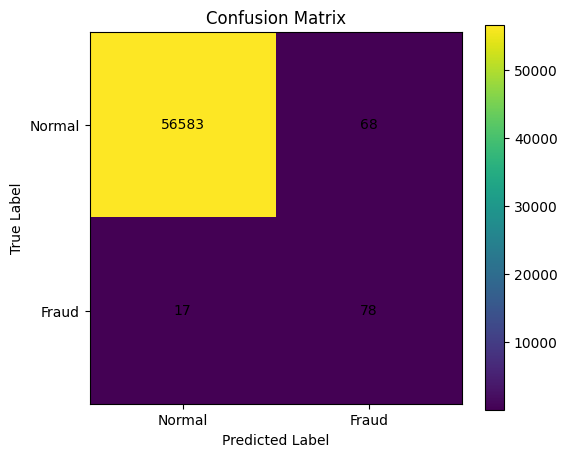

In [44]:
#VISUALIZE CONFUSION MATRIX

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title('Confusion Matrix')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.xticks(
    [0, 1],
    ['Normal', 'Fraud']
)

plt.yticks(
    [0, 1],
    ['Normal', 'Fraud']
)

plt.colorbar()

for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center'
        )

plt.show()

In [45]:
#EXAMPLE OF FINAL DECISION

print("\n====================================")
print("MODEL INFORMATION")
print("====================================")

print("Architecture:")
print("Input → 64 → 32 → 16 → 1")

print("Hidden Activation: ReLU")
print("Output Activation: Sigmoid")
print("Optimizer: Adam")
print("Loss: Binary Cross-Entropy")

print(
    f"Final Threshold: {best_threshold:.2f}"
)


MODEL INFORMATION
Architecture:
Input → 64 → 32 → 16 → 1
Hidden Activation: ReLU
Output Activation: Sigmoid
Optimizer: Adam
Loss: Binary Cross-Entropy
Final Threshold: 0.01


# **AUTOENCODER MODEL**

This section builds an unsupervised **Autoencoder** as a second, independent fraud
detector, and reuses the exact same `X_train` / `y_train` / `X_val` / `y_val` / `X_test` /
`y_test` splits produced above in the MLP's preprocessing section — nothing is
re-loaded or re-split, so both models are guaranteed to be evaluated on the identical
validation and test transactions, which is required for the ensemble step at the end.

**Why a separate scaler for the Autoencoder?** The Autoencoder is trained only on
*normal* (Class=0) transactions, so it — and any statistic used to preprocess its
inputs — should only ever learn from normal data. This is different from the MLP's
scaler above, which is fit on the full (imbalanced) training set. Both scalers are
valid; they just serve two different modeling philosophies.

In [46]:
# Additional imports needed only for the Autoencoder (does not affect the MLP section above)

from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import GaussianNoise
from tensorflow.keras import regularizers
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import RobustScaler

## AE.1 Autoencoder-Specific Data Preparation

In [47]:
# The Autoencoder must only ever see NORMAL transactions during training.
# We reuse the raw (unscaled) X_train / y_train from the MLP's preprocessing section above.

X_train_normal = X_train[y_train == 0]
print("Normal-only training rows for the Autoencoder:", X_train_normal.shape)

# Further split the normal-only training data into a fit set and an early-stopping
# validation set. Both are normal-only, so no fraud information is used to train
# or tune the network's weights.

X_ae_fit, X_ae_earlystop = train_test_split(
    X_train_normal,
    test_size=0.10,
    random_state=42
)

print("AE fit set:", X_ae_fit.shape, " AE early-stopping set:", X_ae_earlystop.shape)

Normal-only training rows for the Autoencoder: (181282, 30)
AE fit set: (163153, 30)  AE early-stopping set: (18129, 30)


## AE.2 Scaling (Autoencoder-Specific Scaler)

In [48]:
# Fit a SEPARATE scaler for the Autoencoder, using ONLY normal-only training rows.
# This does not touch or overwrite the MLP's `scaler` object above.
#
# We use RobustScaler instead of StandardScaler here: it centers/scales using the
# median and interquartile range instead of the mean and standard deviation, which
# makes it far less sensitive to the extreme values in this data. Since the
# Autoencoder's whole signal IS its reconstruction error, we don't want a few
# outlier-driven feature scales distorting what "normal" looks like to begin with.

scaler_ae = RobustScaler()

X_ae_fit_scaled       = scaler_ae.fit_transform(X_ae_fit)
X_ae_earlystop_scaled = scaler_ae.transform(X_ae_earlystop)

# Reuse the SAME raw X_val / X_test from the MLP section, scaled with the AE's own scaler
X_val_scaled_ae  = scaler_ae.transform(X_val)
X_test_scaled_ae = scaler_ae.transform(X_test)

n_features_ae = X_ae_fit_scaled.shape[1]
print("AE input features:", n_features_ae)
print("AE fit scaled shape:", X_ae_fit_scaled.shape)

AE input features: 30
AE fit scaled shape: (163153, 30)


## AE.3 Build the Autoencoder

In [49]:
def build_autoencoder(input_dim):
    inputs = Input(shape=(input_dim,))

    # Denoising: inject small Gaussian noise into the input ONLY during training.
    # At inference time (validation/test scoring) this layer passes data through
    # unchanged, so it does not affect how reconstruction error is measured later -
    # it only affects what the network sees while learning. This forces the network
    # to learn the underlying "normal" manifold rather than memorizing exact values,
    # which should make it react more strongly (higher error) to fraud patterns
    # it has never seen.
    x = GaussianNoise(0.05)(inputs)

    # Light L2 regularization on each layer discourages the network from growing
    # very large weights that could let it "cheat" by reconstructing rare/unusual
    # inputs (including fraud) too well.
    reg = regularizers.l2(1e-5)

    x = Dense(32, activation="relu", kernel_regularizer=reg)(x)
    x = Dense(16, activation="relu", kernel_regularizer=reg)(x)
    bottleneck = Dense(8, activation="relu", kernel_regularizer=reg, name="bottleneck")(x)

    x = Dense(16, activation="relu", kernel_regularizer=reg)(bottleneck)
    x = Dense(32, activation="relu", kernel_regularizer=reg)(x)
    outputs = Dense(input_dim, activation="linear")(x)

    autoencoder = Model(inputs, outputs, name="fraud_autoencoder")
    autoencoder.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse"
    )
    return autoencoder

autoencoder = build_autoencoder(n_features_ae)
autoencoder.summary()

Model: "fraud_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise (GaussianNoise)  │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 30)             │           990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,334 (13.02 KB)

 Trainable params: 3,334 (13.02 KB)

 Non-trainable params: 0 (0.00 B)

## AE.4 Train the Autoencoder

In [50]:
early_stop_ae = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    min_delta=0.0001
)

history_ae = autoencoder.fit(
    X_ae_fit_scaled,
    X_ae_fit_scaled,
    validation_data=(X_ae_earlystop_scaled, X_ae_earlystop_scaled),
    epochs=60,
    batch_size=256,
    shuffle=True,
    callbacks=[early_stop_ae],
    verbose=1
)

Epoch 1/60
638/638 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 1.0192 - val_loss: 0.6444
Epoch 2/60
638/638 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5438 - val_loss: 0.5046
Epoch 3/60
638/638 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4834 - val_loss: 0.4657
Epoch 4/60
638/638 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4487 - val_loss: 0.4294
Epoch 5/60
638/638 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4196 - val_loss: 0.4116
Epoch 6/60
638/638 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4017 - val_loss: 0.3946
Epoch 7/60
638/638 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3886 - val_loss: 0.4119
Epoch 8/60
638/638 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3781 - val_loss: 0.3733
Epoch 9/60
638/638 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3666 - val_loss: 0.3641
Epoch 10/60
638/638 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3586 - val_loss: 0.3547
Epoch 11/60
638/638 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3497 - val_loss: 0.3433
Epoch 12/60
638/638 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

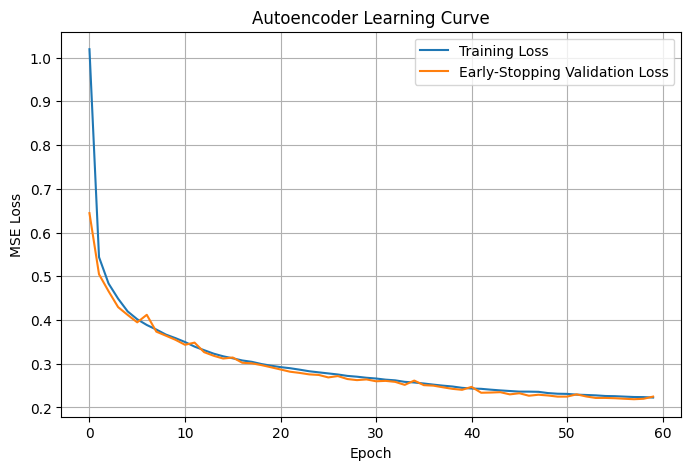

In [51]:
# Autoencoder training curve

plt.figure(figsize=(8, 5))
plt.plot(history_ae.history["loss"], label="Training Loss")
plt.plot(history_ae.history["val_loss"], label="Early-Stopping Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Learning Curve")
plt.legend()
plt.grid(True)
plt.show()

## AE.5 Reconstruction Error as an Anomaly Score

In [52]:
# Feature weights: how strongly each column correlates with the fraud label in the
# TRAINING set (no leakage - only training labels are used here). This makes the
# reconstruction error more sensitive to the columns that actually help separate
# fraud from normal, instead of treating every column as equally important.

feature_correlations = X_train.apply(lambda col: np.abs(np.corrcoef(col, y_train)[0, 1]))
feature_correlations = feature_correlations.fillna(0.0)
feature_weights = (feature_correlations / feature_correlations.sum()).values * len(feature_correlations)

print("Top 5 most heavily-weighted features for the anomaly score:")
print(feature_correlations.sort_values(ascending=False).head())

def reconstruction_error(model, X_scaled, weights=None):
    """Mean squared reconstruction error per row, optionally weighted per feature."""
    X_pred = model.predict(X_scaled, verbose=0)
    squared_error = np.square(X_scaled - X_pred)
    if weights is not None:
        squared_error = squared_error * weights
    return np.mean(squared_error, axis=1)

val_scores_ae  = reconstruction_error(autoencoder, X_val_scaled_ae, weights=feature_weights)
test_scores_ae = reconstruction_error(autoencoder, X_test_scaled_ae, weights=feature_weights)

print("\nValidation reconstruction error - summary:")
print(pd.Series(val_scores_ae).describe())

Top 5 most heavily-weighted features for the anomaly score:
V17    0.317793
V14    0.301248
V12    0.252266
V10    0.208278
V3     0.188354
dtype: float64

Validation reconstruction error - summary:
count    45396.000000
mean         0.270292
std          2.910974
min          0.002923
25%          0.060862
50%          0.110310
75%          0.206927
max        181.879288
dtype: float64


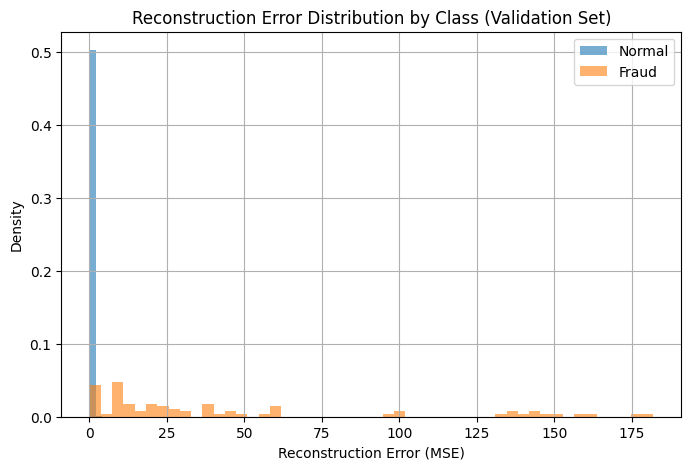

In [53]:
# Visual check: does reconstruction error separate the two classes on the validation set?

plt.figure(figsize=(8, 5))
plt.hist(val_scores_ae[y_val.values == 0], bins=50, alpha=0.6, label="Normal", density=True)
plt.hist(val_scores_ae[y_val.values == 1], bins=50, alpha=0.6, label="Fraud", density=True)
plt.xlabel("Reconstruction Error (MSE)")
plt.ylabel("Density")
plt.title("Reconstruction Error Distribution by Class (Validation Set)")
plt.legend()
plt.grid(True)
plt.show()

## AE.6 Threshold Selection on the Validation Set

We scan the validation set's precision-recall curve and pick the threshold that maximizes the **F2-score**.

F2 gives recall more importance than precision, which matches the fraud-detection goal of catching fraudulent transactions. Unlike maximizing raw recall, F2 does not simply reward predicting every transaction as fraud; it also penalizes the resulting loss of precision.

The threshold is selected on validation data and then applied unchanged to the held-out test set.


In [54]:
precisions_ae, recalls_ae, thresholds_ae = precision_recall_curve(y_val, val_scores_ae)

f2_scores_ae = (
    5 * precisions_ae[:-1] * recalls_ae[:-1]
    / (4 * precisions_ae[:-1] + recalls_ae[:-1] + 1e-10)
)

best_idx_ae = np.argmax(f2_scores_ae)
best_threshold_ae = thresholds_ae[best_idx_ae]

print("Chosen AE threshold (max F2):", best_threshold_ae)
print("  -> Precision at this threshold:", precisions_ae[best_idx_ae])
print("  -> Recall at this threshold   :", recalls_ae[best_idx_ae])
print("  -> F2-score at this threshold :", f2_scores_ae[best_idx_ae])


Chosen AE threshold (max F2): 7.168013770662201
  -> Precision at this threshold: 0.8
  -> Recall at this threshold   : 0.8421052631578947
  -> F2-score at this threshold : 0.833333333312717


## AE.7 Final Evaluation on the Held-Out Test Set

In [55]:
y_test_pred_ae = (test_scores_ae >= best_threshold_ae).astype(int)

accuracy_ae  = accuracy_score(y_test, y_test_pred_ae)
precision_ae = precision_score(y_test, y_test_pred_ae, zero_division=0)
recall_ae    = recall_score(y_test, y_test_pred_ae, zero_division=0)
f1_ae        = f1_score(y_test, y_test_pred_ae, zero_division=0)
roc_auc_ae   = roc_auc_score(y_test, test_scores_ae)
pr_auc_ae    = average_precision_score(y_test, test_scores_ae)

print("\n====================================")
print("AUTOENCODER - FINAL TEST RESULTS")
print("====================================")
print(f"Accuracy : {accuracy_ae*100:.2f}%")
print(f"Precision: {precision_ae*100:.2f}%")
print(f"Recall   : {recall_ae*100:.2f}%")
print(f"F1-Score : {f1_ae*100:.2f}%")
print(f"ROC-AUC  : {roc_auc_ae*100:.2f}%")
print(f"PR-AUC   : {pr_auc_ae*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_ae, digits=4, zero_division=0))

cm_ae = confusion_matrix(y_test, y_test_pred_ae)
print("Confusion Matrix:")
print(cm_ae)


AUTOENCODER - FINAL TEST RESULTS
Accuracy : 99.92%
Precision: 80.23%
Recall   : 72.63%
F1-Score : 76.24%
ROC-AUC  : 94.05%
PR-AUC   : 65.01%

Classification Report:
              precision    recall  f1-score   support

           0     0.9995    0.9997    0.9996     56651
           1     0.8023    0.7263    0.7624        95

    accuracy                         0.9992     56746
   macro avg     0.9009    0.8630    0.8810     56746
weighted avg     0.9992    0.9992    0.9992     56746

Confusion Matrix:
[[56634    17]
 [   26    69]]


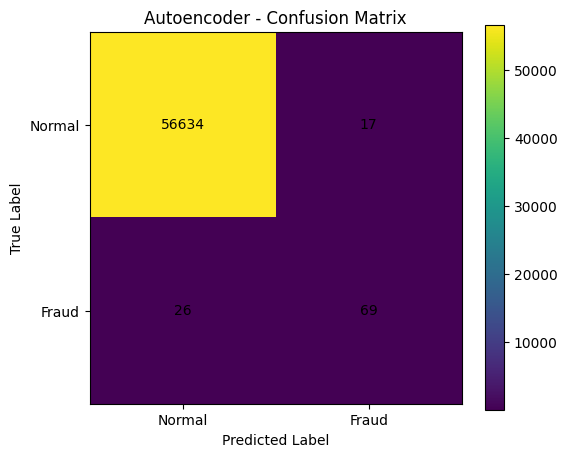

In [56]:
# Visualize Autoencoder confusion matrix

plt.figure(figsize=(6, 5))
plt.imshow(cm_ae)
plt.title("Autoencoder - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1], ["Normal", "Fraud"])
plt.yticks([0, 1], ["Normal", "Fraud"])
plt.colorbar()
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_ae[i, j], ha="center", va="center")
plt.show()

## AE.8 Save Autoencoder Artifacts

In [57]:
autoencoder.save("autoencoder_model.keras")
joblib.dump(scaler_ae, "autoencoder_scaler.pkl")
joblib.dump(best_threshold_ae, "autoencoder_threshold.pkl")

pd.DataFrame({
    "reconstruction_error": val_scores_ae,
    "true_label": y_val.values
}).to_csv("autoencoder_val_scores.csv", index=False)

pd.DataFrame({
    "reconstruction_error": test_scores_ae,
    "true_label": y_test.values
}).to_csv("autoencoder_test_scores.csv", index=False)

print("Saved: autoencoder_model.keras, autoencoder_scaler.pkl, autoencoder_threshold.pkl")
print("Saved: autoencoder_val_scores.csv, autoencoder_test_scores.csv")

Saved: autoencoder_model.keras, autoencoder_scaler.pkl, autoencoder_threshold.pkl
Saved: autoencoder_val_scores.csv, autoencoder_test_scores.csv


# **ENSEMBLE: COMBINING THE MLP AND THE AUTOENCODER**

Both models were evaluated on the exact same validation and test transactions
(`X_val`/`y_val` and `X_test`/`y_test`, shared throughout this notebook), so their
outputs can be combined per-transaction:

- `y_val_prob` / `y_test_prob` — the MLP's predicted probability of fraud (from the MLP
  section above, unchanged).
- `val_scores_ae` / `test_scores_ae` — the Autoencoder's reconstruction error (from the
  Autoencoder section above).

**How they're combined:** rather than picking a fixed weighting by hand, we train a
small **Logistic Regression meta-model** on the validation set, using the two models'
outputs as its only two input features. It learns, from the labeled validation data,
how much weight to give each model's signal. This is a standard technique called
**stacking**. The meta-model's own output is then thresholded using the same
F2-score approach as before, on the validation set, to get the final, third
threshold you asked for.

### Ensemble Architecture

The final system uses **stacking**:

**Input transaction → MLP fraud probability + Autoencoder reconstruction error → Logistic Regression meta-model → Final fraud probability → F2-optimized threshold → Fraud / Normal decision**

The MLP is a supervised classifier, while the Autoencoder is an anomaly detector trained only on normal transactions. The Logistic Regression meta-model learns how to combine these two signals instead of using a manually chosen weight.


## ENS.1 Sanity Check — Alignment Between the Two Models' Outputs

In [58]:
# Both val_scores_ae/test_scores_ae (Autoencoder) and y_val_prob/y_test_prob (MLP) were
# computed from the SAME raw X_val / X_test splits, in the same row order, so they line
# up transaction-for-transaction. We verify the lengths match before combining anything.

assert len(y_val_prob) == len(val_scores_ae) == len(y_val), "Validation arrays misaligned!"
assert len(y_test_prob) == len(test_scores_ae) == len(y_test), "Test arrays misaligned!"

print("Validation arrays aligned:", len(y_val_prob), "rows")
print("Test arrays aligned      :", len(y_test_prob), "rows")

Validation arrays aligned: 45396 rows
Test arrays aligned      : 56746 rows


## ENS.2 Train the Meta-Model on the Validation Set

In [59]:
from sklearn.preprocessing import StandardScaler as MetaScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import make_scorer, fbeta_score

X_meta_val = np.column_stack([y_val_prob, val_scores_ae])
X_meta_test = np.column_stack([y_test_prob, test_scores_ae])

meta_scaler = MetaScaler()
X_meta_val_scaled = meta_scaler.fit_transform(X_meta_val)
X_meta_test_scaled = meta_scaler.transform(X_meta_test)

# LogisticRegressionCV picks its own regularization strength (C) via 5-fold
# cross-validation on the validation set. We now score each candidate C using
# F2 directly (the same metric used everywhere else in this project to choose
# thresholds), instead of average_precision - this aligns what the meta-model
# is being tuned for with what we actually care about at the end.
f2_scorer = make_scorer(fbeta_score, beta=2, zero_division=0)

meta_model = LogisticRegressionCV(
    Cs=10,
    cv=5,
    scoring=f2_scorer,
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

meta_model.fit(X_meta_val_scaled, y_val)

print("Meta-model coefficients (MLP, Autoencoder):", meta_model.coef_)
print("Meta-model intercept:", meta_model.intercept_)
print("Cross-validated regularization strength (C):", meta_model.C_)

combined_val_prob = meta_model.predict_proba(X_meta_val_scaled)[:, 1]
combined_test_prob = meta_model.predict_proba(X_meta_test_scaled)[:, 1]

Meta-model coefficients (MLP, Autoencoder): [[0.27147854 0.08709123]]
Meta-model intercept: [-1.96891195]
Cross-validated regularization strength (C): [0.0001]


## ENS.3 Threshold Selection for the Combined Score

In [60]:
precisions_c, recalls_c, thresholds_c = precision_recall_curve(y_val, combined_val_prob)

f2_scores_c = (
    5 * precisions_c[:-1] * recalls_c[:-1]
    / (4 * precisions_c[:-1] + recalls_c[:-1] + 1e-10)
)

best_idx_c = np.argmax(f2_scores_c)
best_threshold_combined = thresholds_c[best_idx_c]

print("Chosen combined threshold (max F2):", best_threshold_combined)
print("  -> Precision at this threshold:", precisions_c[best_idx_c])
print("  -> Recall at this threshold   :", recalls_c[best_idx_c])
print("  -> F2-score at this threshold :", f2_scores_c[best_idx_c])


Chosen combined threshold (max F2): 0.9844870915479963
  -> Precision at this threshold: 0.8571428571428571
  -> Recall at this threshold   : 0.868421052631579
  -> F2-score at this threshold : 0.8661417322633076


## ENS.4 Final Evaluation of the Combined Model on the Test Set

In [61]:
y_test_pred_combined = (combined_test_prob >= best_threshold_combined).astype(int)

accuracy_c  = accuracy_score(y_test, y_test_pred_combined)
precision_c = precision_score(y_test, y_test_pred_combined, zero_division=0)
recall_c    = recall_score(y_test, y_test_pred_combined, zero_division=0)
f1_c        = f1_score(y_test, y_test_pred_combined, zero_division=0)
roc_auc_c   = roc_auc_score(y_test, combined_test_prob)
pr_auc_c    = average_precision_score(y_test, combined_test_prob)

print("\n====================================")
print("COMBINED (MLP + AUTOENCODER) - FINAL TEST RESULTS")
print("====================================")
print(f"Accuracy : {accuracy_c*100:.2f}%")
print(f"Precision: {precision_c*100:.2f}%")
print(f"Recall   : {recall_c*100:.2f}%")
print(f"F1-Score : {f1_c*100:.2f}%")
print(f"ROC-AUC  : {roc_auc_c*100:.2f}%")
print(f"PR-AUC   : {pr_auc_c*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_combined, digits=4, zero_division=0))

cm_c = confusion_matrix(y_test, y_test_pred_combined)
print("Confusion Matrix:")
print(cm_c)


COMBINED (MLP + AUTOENCODER) - FINAL TEST RESULTS
Accuracy : 99.94%
Precision: 86.90%
Recall   : 76.84%
F1-Score : 81.56%
ROC-AUC  : 95.72%
PR-AUC   : 72.42%

Classification Report:
              precision    recall  f1-score   support

           0     0.9996    0.9998    0.9997     56651
           1     0.8690    0.7684    0.8156        95

    accuracy                         0.9994     56746
   macro avg     0.9343    0.8841    0.9077     56746
weighted avg     0.9994    0.9994    0.9994     56746

Confusion Matrix:
[[56640    11]
 [   22    73]]


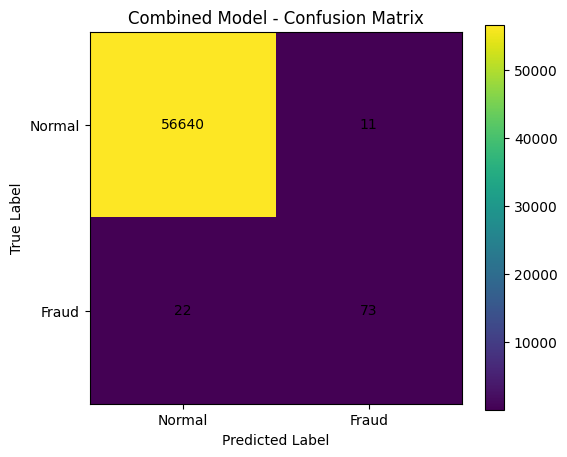

In [62]:
# Visualize combined model confusion matrix

plt.figure(figsize=(6, 5))
plt.imshow(cm_c)
plt.title("Combined Model - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1], ["Normal", "Fraud"])
plt.yticks([0, 1], ["Normal", "Fraud"])
plt.colorbar()
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_c[i, j], ha="center", va="center")
plt.show()

## ENS.5 Side-by-Side Comparison

In [63]:
comparison = pd.DataFrame({
    "MLP Only": [accuracy, precision, recall, f1, roc_auc, pr_auc],
    "Autoencoder Only": [accuracy_ae, precision_ae, recall_ae, f1_ae, roc_auc_ae, pr_auc_ae],
    "Combined (Ensemble)": [accuracy_c, precision_c, recall_c, f1_c, roc_auc_c, pr_auc_c],
}, index=["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", "PR-AUC"])

comparison = comparison * 100
comparison.round(2)

,MLP Only,Autoencoder Only,Combined (Ensemble)
Accuracy,99.85,99.92,99.94
Precision,53.42,80.23,86.90
Recall,82.11,72.63,76.84
F1-Score,64.73,76.24,81.56
ROC-AUC,95.22,94.05,95.72
PR-AUC,79.86,65.01,72.42


## ENS.6 Save the Ensemble Artifacts

In [64]:
joblib.dump(best_threshold, "mlp_threshold.pkl")
joblib.dump(meta_scaler, "ensemble_meta_scaler.pkl")
joblib.dump(meta_model, "ensemble_meta_model.pkl")
joblib.dump(best_threshold_combined, "ensemble_threshold.pkl")

print("Saved: mlp_threshold.pkl, ensemble_meta_scaler.pkl, ensemble_meta_model.pkl, ensemble_threshold.pkl")
print("\nFinal pipeline summary:")
print(f"  MLP threshold        : {best_threshold:.4f}")
print(f"  Autoencoder threshold: {best_threshold_ae:.4f}")
print(f"  Combined threshold   : {best_threshold_combined:.4f}")


Saved: mlp_threshold.pkl, ensemble_meta_scaler.pkl, ensemble_meta_model.pkl, ensemble_threshold.pkl

Final pipeline summary:
  MLP threshold        : 0.0100
  Autoencoder threshold: 7.1680
  Combined threshold   : 0.9845


## 11. Save Deployment Artifacts (Feature Order + Autoencoder Feature Weights)

Two additional artifacts are needed to run inference outside this notebook (e.g. in `app.py`), and were not yet saved above:

- **`feature_columns.pkl`** — the exact final feature order used to build `X` (`X_train.columns`), so a new transaction can be assembled into a DataFrame with the same column order before scaling/prediction.
- **`autoencoder_feature_weights.pkl`** — the per-feature weights (`feature_weights`, computed in section AE.5 from training-label correlations) used inside `reconstruction_error()` to weight the Autoencoder's squared error. Without saving this exact vector, the Autoencoder's reconstruction error could not be reproduced outside this notebook.

Both variables already exist in memory from the cells above — nothing is retrained or recomputed differently, this only persists them to disk.

In [ ]:
# Save feature order and Autoencoder feature weights for deployment.
# These reuse variables already computed above (X_train, feature_weights) - no retraining.

feature_columns = X_train.columns.tolist()
joblib.dump(feature_columns, "feature_columns.pkl")

joblib.dump(feature_weights, "autoencoder_feature_weights.pkl")

print("Saved: feature_columns.pkl")
print("Feature order (", len(feature_columns), "features ):")
print(feature_columns)

print("\nSaved: autoencoder_feature_weights.pkl")
print("Feature weights shape:", feature_weights.shape)
